# Company Founding Years by Industry

This notebook:
1. Fetches all **healthcare** industries + the top industry per non-healthcare sector from Yahoo Finance
2. Gets the top **N** companies by market cap in each selected industry
3. Looks up each company's founding year on Wikipedia (with local caching)
4. Produces two charts comparing **Drug Manufacturers — General** against peers

**Requirements:** `pip install yfinance pandas matplotlib seaborn tqdm requests`

> `yfinance >= 0.2.37` is required for the `Sector` / `Industry` classes.

## Parameters

In [1]:
# ── Parameters ─────────────────────────────────────────────────────────────
N = 3                      # companies per industry (by market cap)
TOP_IND_PER_SECTOR = 1       # how many industries to pick from each non-healthcare sector

FOCUS_INDUSTRY = "drug-manufacturers-general"
FOCUS_SECTOR   = "healthcare"

CACHE_FILE = "founding_year_cache.json"
WIKI_SLEEP = 0.4             # seconds between Wikipedia requests

# Year threshold: if a company's founding year is newer than this,
# chase predecessor/parent links for an older lineage date
SPINOFF_YEAR_THRESHOLD = 2000

# Manual overrides: ticker → founding year
# Use this for companies where Wikipedia's predecessor chain is incomplete
FOUNDING_YEAR_OVERRIDES = {
    "ABBV": 1888,  # Abbott Laboratories lineage
    # "VTRS": 1849,  # Pfizer lineage via Upjohn
}

## Imports

In [2]:
import json
import re
import time
import warnings
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import yfinance as yf
from IPython.display import display
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
print(f"yfinance version: {yf.__version__}")

yfinance version: 1.0


C:\Users\JamesEvans\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Fetch Industries (all healthcare + top per other sector)

In [3]:
SECTOR_KEYS = [
    "technology",
    "healthcare",
    "financial-services",
    "consumer-cyclical",
    "industrials",
    "communication-services",
    "consumer-defensive",
    "energy",
    "real-estate",
    "basic-materials",
    "utilities",
]

industry_records = []

for sector_key in tqdm(SECTOR_KEYS, desc="Sectors"):
    for attempt in range(3):
        try:
            sector = yf.Sector(sector_key)
            industries_df = sector.industries
            if industries_df is None or industries_df.empty:
                break

            rows = []
            for ind_key, ind_row in industries_df.iterrows():
                name = ind_row.get("name", ind_key) if hasattr(ind_row, "get") else ind_key
                rows.append({"sector": sector_key, "industry_key": ind_key, "industry_name": name})

            if sector_key == FOCUS_SECTOR:
                industry_records.extend(rows)
            else:
                industry_records.extend(rows[:TOP_IND_PER_SECTOR])
            break  # success
        except Exception as exc:
            if attempt < 2:
                time.sleep(5 * (attempt + 1))  # back off: 5s, 10s
            else:
                print(f"  [warn] sector '{sector_key}': {exc}")
    time.sleep(2)  # polite pause between sectors

# Ensure focus industry is present
existing_keys = {r["industry_key"] for r in industry_records}
if FOCUS_INDUSTRY not in existing_keys:
    industry_records.append(
        {"sector": FOCUS_SECTOR, "industry_key": FOCUS_INDUSTRY,
         "industry_name": "Drug Manufacturers - General"}
    )
    print(f"  [added] Drug Manufacturers - General (was missing)")

industries = pd.DataFrame(industry_records).drop_duplicates(subset="industry_key")
print(f"\nSelected {len(industries)} industries "
      f"({len(industries[industries['sector']==FOCUS_SECTOR])} healthcare "
      f"+ {len(industries[industries['sector']!=FOCUS_SECTOR])} cross-sector)")
display(industries)

Sectors: 100%|██████████| 11/11 [00:24<00:00,  2.19s/it]


Selected 21 industries (11 healthcare + 10 cross-sector)


,sector,industry_key,industry_name
0,technology,semiconductors,Semiconductors
1,healthcare,drug-manufacturers-general,Drug Manufacturers - General
2,healthcare,biotechnology,Biotechnology
3,healthcare,medical-devices,Medical Devices
4,healthcare,diagnostics-research,Diagnostics & Research
5,healthcare,healthcare-plans,Healthcare Plans
6,healthcare,medical-instruments-supplies,Medical Instruments & Supplies
7,healthcare,medical-distribution,Medical Distribution
8,healthcare,medical-care-facilities,Medical Care Facilities
9,healthcare,drug-manufacturers-specialty-generic,Drug Manufacturers - Specialty & Generic


## Step 2 — Get Top N Companies by Market Cap per Industry

In [4]:
company_records = []

for _, row in tqdm(industries.iterrows(), total=len(industries), desc="Industries"):
    for attempt in range(3):
        try:
            industry = yf.Industry(row["industry_key"])
            top = industry.top_companies
            if top is None or top.empty:
                break
            top = top.head(N)
            for ticker, comp in top.iterrows():
                name = (
                    comp.get("name")
                    or comp.get("longName")
                    or comp.get("shortName")
                    or ticker
                )
                mkt_cap = (
                    comp.get("market cap")
                    or comp.get("marketCap")
                    or comp.get("Market Cap")
                )
                company_records.append(
                    {
                        "ticker": ticker,
                        "name": name,
                        "sector": row["sector"],
                        "industry_key": row["industry_key"],
                        "industry_name": row["industry_name"],
                        "market_cap": mkt_cap,
                    }
                )
            break  # success
        except Exception as exc:
            if attempt < 2:
                time.sleep(5 * (attempt + 1))
            else:
                print(f"  [warn] industry '{row['industry_key']}': {exc}")
    time.sleep(2)

companies = pd.DataFrame(company_records).drop_duplicates(subset="ticker")

if companies.empty:
    raise RuntimeError("No companies were fetched — Yahoo Finance may be rate-limiting. Wait a few minutes and re-run.")

# ── Fetch market caps for companies where top_companies didn't provide them ──
if "market_cap" not in companies.columns:
    companies["market_cap"] = np.nan

missing_mc = companies["market_cap"].isna()
if missing_mc.any():
    print(f"\nFetching market caps for {missing_mc.sum()} companies via fast_info…")
    for idx in tqdm(companies[missing_mc].index, desc="Market caps"):
        ticker = companies.at[idx, "ticker"]
        try:
            info = yf.Ticker(ticker).fast_info
            companies.at[idx, "market_cap"] = info.get("marketCap") or info.get("market_cap")
        except Exception:
            pass
        time.sleep(0.3)

companies["market_cap"] = pd.to_numeric(companies["market_cap"], errors="coerce")
print(f"\nFetched {len(companies)} companies across {companies['industry_key'].nunique()} industries")
print(f"Market cap available for {companies['market_cap'].notna().sum()}/{len(companies)} companies")
display(companies.head(10))

Industries: 100%|██████████| 21/21 [00:45<00:00,  2.15s/it]



Fetching market caps for 60 companies via fast_info…


Market caps: 100%|██████████| 60/60 [00:38<00:00,  1.55it/s]


Fetched 60 companies across 20 industries
Market cap available for 60/60 companies


,ticker,name,sector,industry_key,industry_name,market_cap
0,NVDA,NVIDIA Corporation,technology,semiconductors,Semiconductors,4.071574e+12
1,AVGO,Broadcom Inc.,technology,semiconductors,Semiconductors,1.425606e+12
2,MU,"Micron Technology, Inc.",technology,semiconductors,Semiconductors,4.028492e+11
3,LLY,Eli Lilly and Company,healthcare,drug-manufacturers-general,Drug Manufacturers - General,7.860413e+11
4,JNJ,Johnson & Johnson,healthcare,drug-manufacturers-general,Drug Manufacturers - General,5.794602e+11
5,ABBV,AbbVie Inc.,healthcare,drug-manufacturers-general,Drug Manufacturers - General,3.703788e+11
6,VRTX,Vertex Pharmaceuticals Incorporated,healthcare,biotechnology,Biotechnology,1.100146e+11
7,REGN,"Regeneron Pharmaceuticals, Inc.",healthcare,biotechnology,Biotechnology,7.799056e+10
8,ALNY,"Alnylam Pharmaceuticals, Inc.",healthcare,biotechnology,Biotechnology,4.208928e+10
9,ABT,Abbott Laboratories,healthcare,medical-devices,Medical Devices,1.807016e+11


## Step 3 — Look Up Founding Years via Wikipedia

Results are cached in `founding_year_cache.json` so re-running the notebook is fast.

In [5]:
WIKI_API = "https://en.wikipedia.org/w/api.php"
WIKI_HEADERS = {"User-Agent": "FoundingYearByIndustry/1.0 (research; contact via GitHub)"}

# Year validity range
YEAR_MIN, YEAR_MAX = 1700, 2026


def _extract_year(text: str) -> int | None:
    """Return the first plausible founding year found in *text*, or None."""
    patterns = [
        r"\|\s*(?:founded|foundation|established|incorporated)\s*=\s*[^\n]*?(\d{4})",
        r"[Ff]ounded\s+(?:in\s+)?(\d{4})",
        r"[Ee]stablished\s+(?:in\s+)?(\d{4})",
        r"[Ii]ncorporated\s+(?:in\s+)?(\d{4})",
        r"[Oo]riginally\s+founded\s+(?:in\s+)?(\d{4})",
    ]
    for pat in patterns:
        m = re.search(pat, text)
        if m:
            yr = int(m.group(1))
            if YEAR_MIN <= yr <= YEAR_MAX:
                return yr
    return None


def _extract_wiki_links(text: str) -> list[str]:
    """Extract all [[Target]] or [[Target|Display]] wiki link targets from text."""
    return re.findall(r"\[\[([^\]|]+?)(?:\|[^\]]+)?\]\]", text)


def _extract_predecessors(wikitext: str) -> list[str]:
    """Extract predecessor/parent company names from infobox + body text."""
    predecessors = []

    # 1. Infobox fields: predecessor(s), parent, formerly
    #    Only match the value on the SAME LINE as the field (no DOTALL)
    for field in ["predecessors?", "parent", "formerly"]:
        pat = rf"\|\s*{field}\s*=\s*(.+)"
        m = re.search(pat, wikitext, re.IGNORECASE)
        if m:
            raw = m.group(1).strip()
            if not raw:
                continue
            # Also grab continuation lines (for {{ubl|...}} spanning lines)
            start = m.end()
            while start < len(wikitext):
                next_nl = wikitext.find("\n", start)
                if next_nl == -1:
                    break
                next_line = wikitext[next_nl + 1:wikitext.find("\n", next_nl + 1)] if next_nl + 1 < len(wikitext) else ""
                if next_line.strip().startswith("|") or next_line.strip().startswith("}}"):
                    break
                raw += " " + next_line.strip()
                start = next_nl + 1

            links = _extract_wiki_links(raw)
            if links:
                predecessors.extend(links)
            else:
                clean = re.sub(r"<[^>]+>|\{\{[^}]*\}\}|'{2,}", "", raw).strip()
                if clean and len(clean) < 100:
                    predecessors.append(clean)

    # 2. Body text fallback: look for spin-off / parent references
    if not predecessors:
        body = wikitext
        infobox_end = wikitext.find("\n}}")
        if infobox_end > 0:
            body = wikitext[infobox_end:]

        # Patterns where the link comes AFTER the phrase
        after_patterns = [
            r"spun\s+off\s+from\s+[^.\n]*?\[\[([^\]|]+)",
            r"spin[- ]?off\s+(?:of|from)\s+[^.\n]*?\[\[([^\]|]+)",
            r"split\s+(?:off|from)\s+[^.\n]*?\[\[([^\]|]+)",
            r"carved?\s+out\s+(?:of|from)\s+[^.\n]*?\[\[([^\]|]+)",
            r"separated?\s+from\s+[^.\n]*?\[\[([^\]|]+)",
            r"(?:was|were)\s+(?:a\s+)?(?:subsidiary|division|unit)\s+of\s+[^.\n]*?\[\[([^\]|]+)",
        ]
        # Patterns where the link comes BEFORE the phrase
        # e.g. "[[Abbott Laboratories|Abbott]], the name of its former parent company"
        before_patterns = [
            r"\[\[([^\]|]+?)(?:\|[^\]]+)?\]\][^.\n]{0,60}(?:former|ex)[- ]parent",
            r"\[\[([^\]|]+?)(?:\|[^\]]+)?\]\][^.\n]{0,60}(?:spun\s+off|spin[- ]?off|split\s+off)",
            r"\[\[([^\]|]+?)(?:\|[^\]]+)?\]\][^.\n]{0,60}(?:parent\s+company)",
        ]
        for pat in before_patterns + after_patterns:
            m = re.search(pat, body, re.IGNORECASE)
            if m:
                name = m.group(1).strip()
                if name and name not in predecessors:
                    predecessors.append(name)

    # Filter out non-company links
    skip = {"United States", "New York", "Delaware", "Public company", "Latin",
            "NYSE", "NASDAQ", "S&P 500", "S&P 100"}
    return [p for p in predecessors if p not in skip]


def _fetch_wikitext(page_title: str) -> str:
    """Fetch section-0 wikitext for a Wikipedia page title."""
    resp = requests.get(
        WIKI_API,
        params={
            "action": "parse",
            "page": page_title,
            "prop": "wikitext",
            "section": 0,
            "format": "json",
        },
        headers=WIKI_HEADERS,
        timeout=12,
    )
    return resp.json().get("parse", {}).get("wikitext", {}).get("*", "")


def _search_wikipedia(query: str) -> str | None:
    """Return the top Wikipedia page title for a search query, or None."""
    resp = requests.get(
        WIKI_API,
        params={
            "action": "query",
            "list": "search",
            "srsearch": query,
            "srlimit": 1,
            "srnamespace": 0,
            "format": "json",
        },
        headers=WIKI_HEADERS,
        timeout=12,
    )
    results = resp.json().get("query", {}).get("search", [])
    return results[0]["title"] if results else None


def get_founding_year(company_name: str, max_hops: int = 3) -> int | None:
    """
    Search Wikipedia for *company_name* and return its founding year.
    If the year is recent (> SPINOFF_YEAR_THRESHOLD), chase predecessor/parent
    links up to *max_hops* times to find the oldest lineage date.
    """
    try:
        # 1. Search for the company page
        resp = requests.get(
            WIKI_API,
            params={
                "action": "query",
                "list": "search",
                "srsearch": company_name,
                "srlimit": 3,
                "srnamespace": 0,
                "format": "json",
            },
            headers=WIKI_HEADERS,
            timeout=12,
        )
        results = resp.json()["query"]["search"]
        if not results:
            return None

        # Try each search result until we find a year
        best_year = None
        wikitext = ""
        for result in results:
            page_title = result["title"]
            time.sleep(WIKI_SLEEP)
            wikitext = _fetch_wikitext(page_title)
            yr = _extract_year(wikitext)
            if yr:
                best_year = yr
                break

        if best_year is None:
            return None

        # 2. If recent, chase predecessor/parent chain for older lineage
        if best_year > SPINOFF_YEAR_THRESHOLD:
            visited = {company_name.lower()}
            current_wikitext = wikitext
            for _ in range(max_hops):
                predecessors = _extract_predecessors(current_wikitext)
                found_older = False
                for pred_name in predecessors:
                    if pred_name.lower() in visited:
                        continue
                    visited.add(pred_name.lower())
                    time.sleep(WIKI_SLEEP)

                    # Try direct page fetch first, fall back to search
                    try:
                        pred_wikitext = _fetch_wikitext(pred_name)
                    except Exception:
                        pred_wikitext = ""
                    if not pred_wikitext or "missing" in str(pred_wikitext)[:50]:
                        title = _search_wikipedia(pred_name)
                        if title:
                            time.sleep(WIKI_SLEEP)
                            pred_wikitext = _fetch_wikitext(title)

                    if not pred_wikitext:
                        continue

                    pred_yr = _extract_year(pred_wikitext)
                    if pred_yr and pred_yr < best_year:
                        best_year = pred_yr
                        current_wikitext = pred_wikitext
                        found_older = True
                        break  # follow this chain deeper
                if not found_older:
                    break  # no older predecessor found

        return best_year
    except Exception:
        return None


# ── Quick self-test on AbbVie and Viatris ─────────────────────────────────
for test_name in ["AbbVie Inc.", "Viatris Inc."]:
    yr = get_founding_year(test_name)
    print(f"  {test_name}: {yr}")
print("\nFounding-year helper defined (with predecessor chasing).")

  AbbVie Inc.: 2012
  Viatris Inc.: 1961

Founding-year helper defined (with predecessor chasing).


In [6]:
# Load existing cache
cache_path = Path(CACHE_FILE)
cache: dict[str, int | None] = {}
if cache_path.exists():
    with cache_path.open() as f:
        raw_cache = json.load(f)
    # Only keep entries that actually found a year (drop None / failed lookups)
    cache = {k: v for k, v in raw_cache.items() if v is not None}
    dropped = len(raw_cache) - len(cache)
    print(f"Loaded {len(cache)} cached entries from {CACHE_FILE}" +
          (f" (dropped {dropped} failed lookups)" if dropped else ""))

# Apply manual overrides (always take precedence)
for ticker, yr in FOUNDING_YEAR_OVERRIDES.items():
    cache[ticker] = yr
if FOUNDING_YEAR_OVERRIDES:
    print(f"Applied {len(FOUNDING_YEAR_OVERRIDES)} manual override(s)")

to_fetch = [row for _, row in companies.iterrows() if row["ticker"] not in cache]
print(f"{len(cache)} already cached, {len(to_fetch)} to fetch from Wikipedia…")

for row in tqdm(to_fetch, desc="Wikipedia"):
    ticker = row["ticker"]
    name = str(row["name"]) if row["name"] else ticker
    yr = get_founding_year(name)
    if yr is not None:
        cache[ticker] = yr
    time.sleep(WIKI_SLEEP)

# Persist updated cache (only successful lookups)
with cache_path.open("w") as f:
    json.dump(cache, f, indent=2)

companies["founding_year"] = companies["ticker"].map(cache)

found = companies["founding_year"].notna().sum()
print(f"\nFounding year found for {found}/{len(companies)} companies ({found/len(companies):.0%})")

# Show companies where predecessor chasing may have kicked in
recent = companies[companies["founding_year"].notna()].copy()
recent["founding_year"] = recent["founding_year"].astype(int)
spinoffs = recent[recent["founding_year"] <= SPINOFF_YEAR_THRESHOLD]
if not spinoffs.empty:
    print(f"\nCompanies with lineage-adjusted founding years (≤ {SPINOFF_YEAR_THRESHOLD}):")
    display(spinoffs[["ticker", "name", "industry_name", "founding_year"]].sort_values("founding_year"))

Loaded 60 cached entries from founding_year_cache.json
Applied 1 manual override(s)
60 already cached, 0 to fetch from Wikipedia…


Wikipedia: 0it [00:00, ?it/s]


Founding year found for 60/60 companies (100%)

Companies with lineage-adjusted founding years (≤ 2000):


,ticker,name,industry_name,founding_year
21,MCK,McKesson Corporation,Medical Distribution,1833
55,SHW,The Sherwin-Williams Company,Specialty Chemicals,1866
3,LLY,Eli Lilly and Company,Drug Manufacturers - General,1876
54,LIN,Linde plc,Specialty Chemicals,1879
4,JNJ,Johnson & Johnson,Drug Manufacturers - General,1886
5,ABBV,AbbVie Inc.,Drug Manufacturers - General,1888
9,ABT,Abbott Laboratories,Medical Devices,1888
19,BDX,"Becton, Dickinson and Company",Medical Instruments & Supplies,1897
50,NFG,National Fuel Gas Company,Oil & Gas Integrated,1902
47,TGT,Target Corporation,Discount Stores,1902


## Step 4 — Visualize

**Chart 1** — Drug Manufacturers vs every other healthcare industry  
**Chart 2** — Drug Manufacturers vs the top industry from each sector

In [7]:
# ── Prep data ──────────────────────────────────────────────────────────────
plot_df = companies.dropna(subset=["founding_year", "market_cap"]).copy()
plot_df["founding_year"] = plot_df["founding_year"].astype(int)

# Resolve the display name for the focus industry
focus_name = industries.loc[
    industries["industry_key"] == FOCUS_INDUSTRY, "industry_name"
].iloc[0]

# Split into the two chart subsets
healthcare_df = plot_df[plot_df["sector"] == FOCUS_SECTOR].copy()
cross_sector_df = plot_df[
    (plot_df["sector"] != FOCUS_SECTOR) | (plot_df["industry_key"] == FOCUS_INDUSTRY)
].copy()

# ── Palettes ──────────────────────────────────────────────────────────────
# Chart 1: healthcare industries
hc_industries = sorted(healthcare_df["industry_name"].unique())
hc_palette = dict(zip(
    hc_industries,
    sns.color_palette("tab20", n_colors=len(hc_industries)),
))
# Make the focus industry stand out
hc_palette[focus_name] = sns.color_palette("bright")[3]  # red

# Chart 2: cross-sector industries
xs_industries = sorted(cross_sector_df["industry_name"].unique())
xs_palette = dict(zip(
    xs_industries,
    sns.color_palette("tab10", n_colors=len(xs_industries)),
))
xs_palette[focus_name] = sns.color_palette("bright")[3]  # red

print(f"Chart 1: {len(healthcare_df)} companies across {len(hc_industries)} healthcare industries")
print(f"Chart 2: {len(cross_sector_df)} companies across {len(xs_industries)} industries (1 per sector + focus)")

Chart 1: 30 companies across 10 healthcare industries
Chart 2: 33 companies across 11 industries (1 per sector + focus)


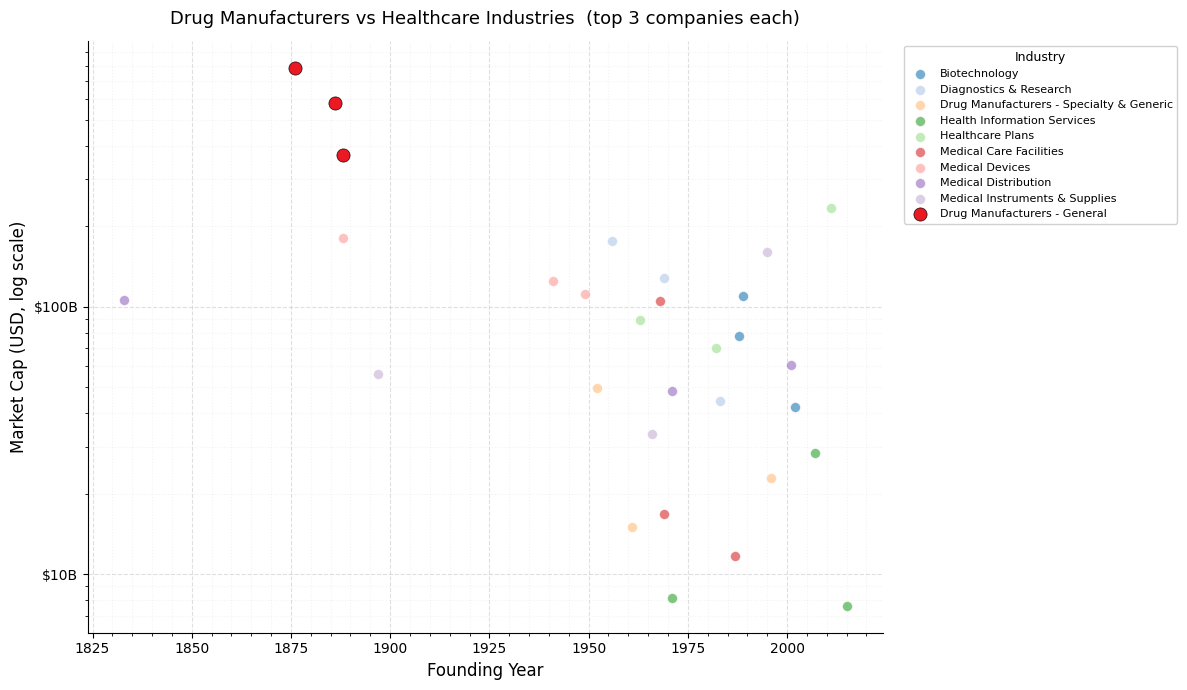

Saved → chart1_healthcare.png


In [8]:
# ── Helper to draw the dot chart ──────────────────────────────────────────
def _dot_chart(df, palette, industry_order, title, filename):
    """Scatter: x = founding year, y = market cap (log), color = industry."""
    fig, ax = plt.subplots(figsize=(12, 7))

    for ind_name in industry_order:
        subset = df[df["industry_name"] == ind_name]
        is_focus = ind_name == focus_name
        ax.scatter(
            subset["founding_year"],
            subset["market_cap"],
            color=palette[ind_name],
            alpha=0.9 if is_focus else 0.6,
            s=90 if is_focus else 50,
            linewidths=0.5,
            edgecolors="black" if is_focus else "white",
            label=ind_name,
            zorder=4 if is_focus else 3,
        )

    ax.set_yscale("log")
    ax.set_xlabel("Founding Year", fontsize=12)
    ax.set_ylabel("Market Cap (USD, log scale)", fontsize=12)
    ax.set_title(title, fontsize=13, pad=12)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"${x/1e12:.1f}T" if x >= 1e12
        else f"${x/1e9:.0f}B" if x >= 1e9
        else f"${x/1e6:.0f}M" if x >= 1e6
        else f"${x:.0f}"
    ))
    ax.xaxis.set_major_locator(mticker.MultipleLocator(25))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))
    ax.grid(which="major", linestyle="--", alpha=0.4, zorder=0)
    ax.grid(which="minor", linestyle=":", alpha=0.15, zorder=0)
    ax.set_axisbelow(True)

    ax.legend(
        bbox_to_anchor=(1.02, 1), loc="upper left",
        fontsize=8, framealpha=0.9,
        title="Industry", title_fontsize=9,
    )
    sns.despine()
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {filename}")


# ── Chart 1: Drug Manufacturers vs other healthcare industries ────────────
_dot_chart(
    healthcare_df,
    hc_palette,
    # Draw focus industry last so it renders on top
    [i for i in hc_industries if i != focus_name] + [focus_name],
    f"Drug Manufacturers vs Healthcare Industries  (top {N} companies each)",
    "chart1_healthcare.png",
)

In [9]:
# ── Chart 1 data: Healthcare companies ────────────────────────────────────
_tbl1 = (
    healthcare_df[["ticker", "name", "industry_name", "founding_year", "market_cap"]]
    .sort_values(["industry_name", "founding_year"])
    .reset_index(drop=True)
)
_tbl1["founding_year"] = _tbl1["founding_year"].astype(int)
_tbl1["market_cap_fmt"] = _tbl1["market_cap"].apply(
    lambda x: f"${x/1e12:.1f}T" if x >= 1e12
    else f"${x/1e9:.1f}B" if x >= 1e9
    else f"${x/1e6:.0f}M"
)
display(_tbl1[["ticker", "name", "industry_name", "founding_year", "market_cap_fmt"]]
        .rename(columns={"market_cap_fmt": "market_cap"}))

,ticker,name,industry_name,founding_year,market_cap
0,REGN,"Regeneron Pharmaceuticals, Inc.",Biotechnology,1988,$78.0B
1,VRTX,Vertex Pharmaceuticals Incorporated,Biotechnology,1989,$110.0B
2,ALNY,"Alnylam Pharmaceuticals, Inc.",Biotechnology,2002,$42.1B
3,TMO,Thermo Fisher Scientific Inc.,Diagnostics & Research,1956,$175.8B
4,DHR,Danaher Corporation,Diagnostics & Research,1969,$128.5B
5,IDXX,"IDEXX Laboratories, Inc.",Diagnostics & Research,1983,$44.6B
6,LLY,Eli Lilly and Company,Drug Manufacturers - General,1876,$786.0B
7,JNJ,Johnson & Johnson,Drug Manufacturers - General,1886,$579.5B
8,ABBV,AbbVie Inc.,Drug Manufacturers - General,1888,$370.4B
9,ZTS,Zoetis Inc.,Drug Manufacturers - Specialty & Generic,1952,$50.0B


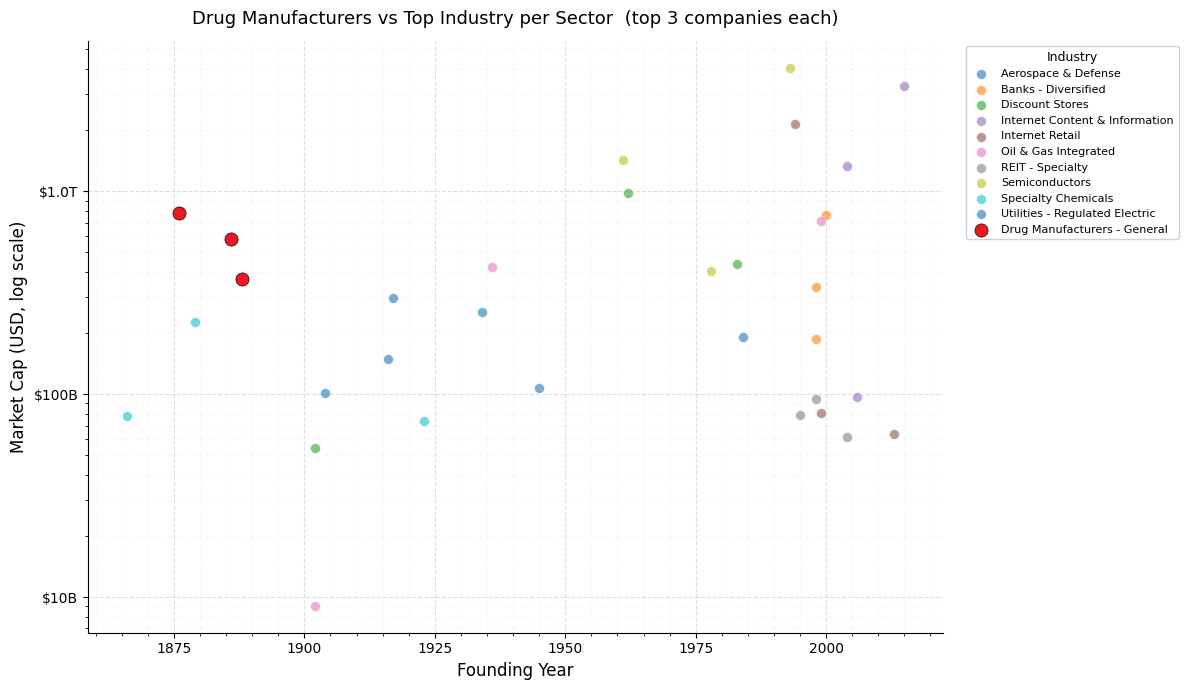

Saved → chart2_cross_sector.png


In [10]:
# ── Chart 2: Drug Manufacturers vs top industry from each sector ──────────
_dot_chart(
    cross_sector_df,
    xs_palette,
    [i for i in xs_industries if i != focus_name] + [focus_name],
    f"Drug Manufacturers vs Top Industry per Sector  (top {N} companies each)",
    "chart2_cross_sector.png",
)

In [11]:
# ── Chart 2 data: Cross-sector companies ──────────────────────────────────
_tbl2 = (
    cross_sector_df[["ticker", "name", "industry_name", "sector", "founding_year", "market_cap"]]
    .sort_values(["sector", "industry_name", "founding_year"])
    .reset_index(drop=True)
)
_tbl2["founding_year"] = _tbl2["founding_year"].astype(int)
_tbl2["market_cap_fmt"] = _tbl2["market_cap"].apply(
    lambda x: f"${x/1e12:.1f}T" if x >= 1e12
    else f"${x/1e9:.1f}B" if x >= 1e9
    else f"${x/1e6:.0f}M"
)
display(_tbl2[["ticker", "name", "industry_name", "sector", "founding_year", "market_cap_fmt"]]
        .rename(columns={"market_cap_fmt": "market_cap"}))

,ticker,name,industry_name,sector,founding_year,market_cap
0,SHW,The Sherwin-Williams Company,Specialty Chemicals,basic-materials,1866,$78.1B
1,LIN,Linde plc,Specialty Chemicals,basic-materials,1879,$227.6B
2,ECL,Ecolab Inc.,Specialty Chemicals,basic-materials,1923,$73.8B
3,META,"Meta Platforms, Inc.",Internet Content & Information,communication-services,2004,$1.3T
4,SPOT,Spotify Technology S.A.,Internet Content & Information,communication-services,2006,$97.3B
5,GOOG,Alphabet Inc.,Internet Content & Information,communication-services,2015,$3.3T
6,AMZN,"Amazon.com, Inc.",Internet Retail,consumer-cyclical,1994,$2.1T
7,MELI,"MercadoLibre, Inc.",Internet Retail,consumer-cyclical,1999,$81.1B
8,DASH,"DoorDash, Inc.",Internet Retail,consumer-cyclical,2013,$63.7B
9,TGT,Target Corporation,Discount Stores,consumer-defensive,1902,$54.3B


In [12]:
# ── Summary table ──────────────────────────────────────────────────────────
summary = (
    plot_df.groupby(["sector", "industry_name"])["founding_year"]
    .agg(["median", "min", "max", "count"])
    .rename(columns={"median": "median_year", "min": "oldest", "max": "newest", "count": "n"})
    .sort_values("median_year")
    .reset_index()
)
summary["median_year"] = summary["median_year"].astype(int)
display(summary)

companies.to_csv("companies_with_founding_years.csv", index=False)
print("\nFull results saved → companies_with_founding_years.csv")

,sector,industry_name,median_year,oldest,newest,n
0,basic-materials,Specialty Chemicals,1879,1866,1923,3
1,healthcare,Drug Manufacturers - General,1886,1876,1888,3
2,industrials,Aerospace & Defense,1917,1916,1934,3
3,energy,Oil & Gas Integrated,1936,1902,1999,3
4,healthcare,Medical Devices,1941,1888,1949,3
5,utilities,Utilities - Regulated Electric,1945,1904,1984,3
6,healthcare,Drug Manufacturers - Specialty & Generic,1961,1952,1996,3
7,consumer-defensive,Discount Stores,1962,1902,1983,3
8,healthcare,Medical Instruments & Supplies,1966,1897,1995,3
9,healthcare,Diagnostics & Research,1969,1956,1983,3



Full results saved → companies_with_founding_years.csv
